Single-case impact parameter b = 1.000e-09 m
Simulated ion energy gain: 7.723878e-30 J
Analytic ion energy gain: 7.743113e-30 J


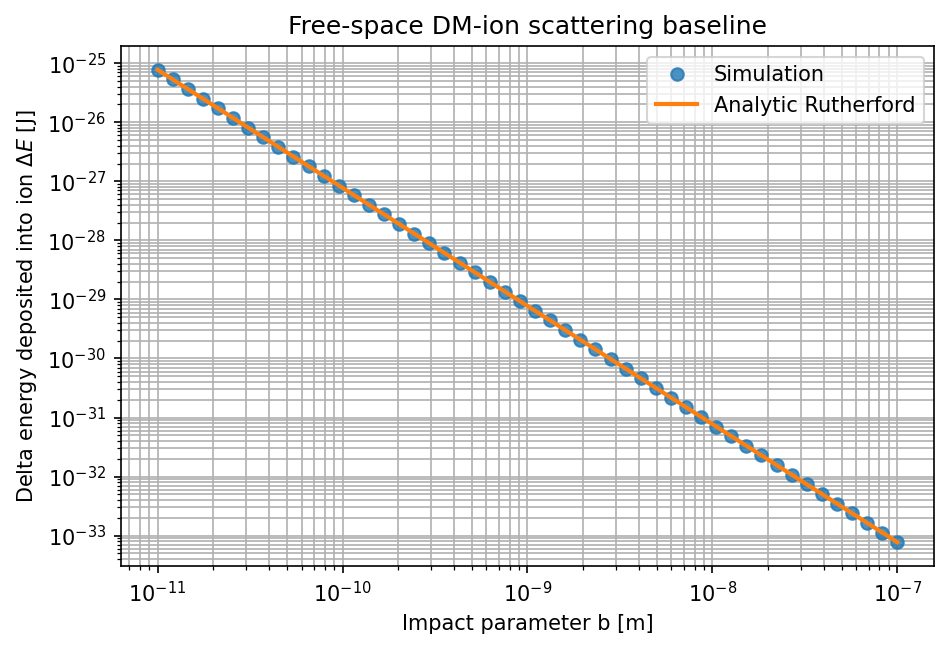

In [6]:
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import Image, display

# Physical constants in SI
elementary_charge = 1.602e-19  # C
k_e = 8.988e9  # N m^2 / C^2
mass_dm = 1e-27  # kg
mass_ion = 171 * 1.66053907e-27  # kg, Yb-171
epsilon = 1e-3  # dimensionless DM-ion coupling
v_dm = 220e3  # m/s


def equations_of_motion(t, state, q_strength=epsilon * elementary_charge):
    x_dm = state[0:3]
    v_dm = state[3:6]
    x_ion = state[6:9]
    v_ion = state[9:12]

    sep = x_dm - x_ion
    dist = np.linalg.norm(sep)
    if dist < 1e-30:
        force_vec = np.zeros(3)
    else:
        force_vec = k_e * q_strength * elementary_charge * sep / (dist**3)

    a_dm = force_vec / mass_dm
    a_ion = -force_vec / mass_ion
    return np.concatenate([v_dm, a_dm, v_ion, a_ion])


def run_scattering(b):
    x_dm0 = np.array([-10 * b, b, 0.0])
    v_dm0 = np.array([v_dm, 0.0, 0.0])
    state0 = np.concatenate([x_dm0, v_dm0, np.zeros(3), np.zeros(3)])

    def event_distance(t, state, b_local=b):
        return np.linalg.norm(state[0:3] - state[6:9]) - 10 * b_local

    event_distance.terminal = True
    event_distance.direction = 1

    solution = solve_ivp(
        equations_of_motion,
        (0.0, 1e-10),
        state0,
        method='RK45',
        rtol=1e-9,
        atol=1e-12,
        args=(epsilon * elementary_charge,),
        events=event_distance,
    )

    if solution.success and solution.y.size > 0:
        v_ion_final = solution.y[9:12, -1]
        delta_E_sim = 0.5 * mass_ion * np.dot(v_ion_final, v_ion_final)
    else:
        delta_E_sim = np.nan

    mu = mass_dm * mass_ion / (mass_dm + mass_ion)
    b0 = k_e * epsilon * elementary_charge**2 / (mu * v_dm**2)
    delta_E_analytic = (2 * mu**2 * v_dm**2 / mass_ion) / (1 + (b / b0)**2)
    return delta_E_sim, delta_E_analytic


# Single-case demonstration
b_single = 1e-9
delta_E_sim, delta_E_analytic = run_scattering(b_single)
print(f"Single-case impact parameter b = {b_single:.3e} m")
print(f"Simulated ion energy gain: {delta_E_sim:.6e} J")
print(f"Analytic ion energy gain: {delta_E_analytic:.6e} J")

# Sweep over impact parameters and compare simulation to Rutherford formula
b_values = np.logspace(-11, -7, 50)
delta_E_sims = np.empty_like(b_values, dtype=float)
delta_E_analytics = np.empty_like(b_values, dtype=float)

for i, b_val in enumerate(b_values):
    delta_E_sims[i], delta_E_analytics[i] = run_scattering(float(b_val))

plt.figure(figsize=(7, 4.5))
plt.loglog(b_values, delta_E_sims, 'o', label='Simulation', alpha=0.8)
plt.loglog(b_values, delta_E_analytics, '-', label='Analytic Rutherford', linewidth=2)
plt.xlabel('Impact parameter b [m]')
plt.ylabel(r'Delta energy deposited into ion $\Delta E$ [J]')
plt.title('Free-space DM-ion scattering baseline')
plt.grid(True, which='both')
plt.legend()
# Save to file and explicitly display (works in VS Code & Jupyter outputs)
plot_file = 'rutherford_scatter.png'
plt.savefig(plot_file, dpi=150, bbox_inches='tight')
display(Image(filename=plot_file))
plt.close()
